# HeatSense Phase 0 — XGBoost Baseline with Enriched Features

**Goal:** Prove that core temperature is predictable from wearable-feasible features before building any neural network.

**Key additions over V1-V3:**
- `time_in_session` (r=0.72 — strongest predictor, was missing from all CNN models)
- `cumulative_HR` (metabolic heat storage proxy)
- `Perceptual_TS` and `Perceptual_TC` (forward-filled, 99.9% coverage after ffill)
- `activity_workrest` (work vs rest phase, 100% coverage)
- Dropped `Env_Humidity` (r=0.04, interaction p=0.96)
- Sample weighting for elevated Tcore
- Leave-participants-out cross-validation

## 1. Setup & Configuration

In [ ]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    print("Installing xgboost...")
    import subprocess
    subprocess.check_call(['pip', 'install', '-q', 'xgboost'])
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")

from google.colab import drive
drive.mount('/content/drive')

# --- Paths ---
DATA_DIR = '/content/drive/MyDrive/HeatSense'
RAW_DATA_PATH = os.path.join(DATA_DIR, 'sen_ds_raw.xlsx')
DATA_SHEET = 'Data'
OUTPUT_DIR = os.path.join(DATA_DIR, 'output')

# --- Reproducibility ---
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Column renames ---
COLUMN_RENAME = {
    'SkinTemp_upper_arm': 'SkinTemp_UpperArm',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Temp': 'Env_Temp',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Humidity': 'Env_Humidity',
    'InsulatedskinTemp_HR': 'HR',
    'Activity_code': 'Activity_Code',
    'Bodymasskg': 'Body_Mass_Kg',
    'Heightcm': 'Height_Cm',
    'Bodyfat%': 'Body_Fat_Pct',
    'VO2peakmlkgmin': 'VO2Peak',
    'Acclimationstatus': 'Acclimation_Status',
    'Trainingstatus': 'Training_Status',
}

MISSING_SENTINEL = 9999
TARGET = 'Corerectal'

# --- Feature configuration ---
WINDOW_SIZE = 30
TRAIN_STRIDE = 5
EVAL_STRIDE = 5

# Weighted loss for elevated Tcore
ELEVATED_WEIGHT_ALPHA = 5.0
ELEVATED_WEIGHT_THRESHOLD = 37.5

# Split
TEST_SIZE = 0.30
VAL_FRACTION = 0.50

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup complete.")
print(f"  Data: {RAW_DATA_PATH}")

XGBoost version: 3.2.0
Mounted at /content/drive
Setup complete.
  Data: /content/drive/MyDrive/HeatSense/sen_ds_raw.xlsx


## 2. Load & Clean Data

In [ ]:
# ============================================================
# LOAD RAW DATA
# ============================================================

def flatten_multiindex(df):
    new_cols = []
    for col in df.columns:
        lvl0 = str(col[0]).strip()
        lvl1 = str(col[1]).strip()
        if 'Unnamed' in lvl0:
            new_cols.append(lvl1)
        elif lvl0 == lvl1:
            new_cols.append(lvl0)
        else:
            new_cols.append(f"{lvl0}_{lvl1}")
    df.columns = new_cols
    df.columns = [c.split('_Unnamed')[0].strip().replace(' ', '_') for c in df.columns]
    return df

print("Loading raw data...")
df = pd.read_excel(RAW_DATA_PATH, sheet_name=DATA_SHEET, header=[0, 1])
df = flatten_multiindex(df)
df.rename(columns=COLUMN_RENAME, inplace=True)
df.replace([MISSING_SENTINEL, float(MISSING_SENTINEL)], np.nan, inplace=True)

# Session identification
df['Time_Sec'] = pd.to_timedelta(df['Time'].astype(str), errors='coerce').dt.total_seconds()
df['Session_ID'] = (
    (df['Participant'] != df['Participant'].shift(1)) |
    (df['Time_Sec'] < df['Time_Sec'].shift(1))
).cumsum()

# Forward-fill HR within sessions (handles P1-P18 5-min sampling)
before_nan = df['HR'].isna().sum()
for sid in df['Session_ID'].unique():
    mask = df['Session_ID'] == sid
    df.loc[mask, 'HR'] = df.loc[mask, 'HR'].ffill(limit=5)
after_nan = df['HR'].isna().sum()
print(f"  HR forward-fill: {before_nan - after_nan} NaN resolved, {after_nan} remain")

# Forward-fill perceptual inputs within sessions (recorded every ~10 min)
perceptual_cols = ['Perceptual_TS', 'Perceptual_TC']
# Find the actual column names (may have multi-index remnants)
actual_perceptual = {}
for target_name in perceptual_cols:
    matches = [c for c in df.columns if target_name.replace('Perceptual_', '') in c and 'Perceptual' in c]
    if matches:
        actual_perceptual[target_name] = matches[0]

print(f"  Perceptual columns found: {actual_perceptual}")

for nice_name, real_name in actual_perceptual.items():
    before_p = df[real_name].isna().sum()
    for sid in df['Session_ID'].unique():
        mask = df['Session_ID'] == sid
        df.loc[mask, real_name] = df.loc[mask, real_name].ffill()
    after_p = df[real_name].isna().sum()
    # Rename to clean name
    if real_name != nice_name:
        df.rename(columns={real_name: nice_name}, inplace=True)
    print(f"  {nice_name}: ffill {before_p - after_p} NaN -> {after_p} remain "
          f"({(1 - after_p/len(df))*100:.1f}% coverage)")

# Activity work/rest - find column
workrest_candidates = [c for c in df.columns if 'workrest' in c.lower() or 'work_rest' in c.lower()]
if workrest_candidates:
    df.rename(columns={workrest_candidates[0]: 'Activity_Workrest'}, inplace=True)
    print(f"  Activity_Workrest: {df['Activity_Workrest'].notna().sum()}/{len(df)} rows")
else:
    # Try to find it in the raw columns
    for c in df.columns:
        if 'Activity' in c and 'workrest' in c.lower():
            df.rename(columns={c: 'Activity_Workrest'}, inplace=True)
            break
    if 'Activity_Workrest' not in df.columns:
        print("  WARNING: Activity_Workrest column not found!")
        # Check all activity-related columns
        act_cols = [c for c in df.columns if 'ctiv' in c.lower()]
        print(f"  Activity-related columns: {act_cols}")

# Encode features
df['Sex_Encoded'] = df['Sex'].map({1: 1, 2: 0, '1': 1, '2': 0}).fillna(1).astype('float32')
height_m = (df['Height_Cm'] / 100).replace(0, np.nan)
df['BMI'] = (df['Body_Mass_Kg'] / (height_m ** 2)).astype('float32')
df['Acclimation_Encoded'] = df['Acclimation_Status'].astype('float32')
df['Training_Encoded'] = df['Training_Status'].map({1: 1, 2: 0}).fillna(0).astype('float32')

# Drop rows with no target
before = len(df)
df = df.dropna(subset=[TARGET]).copy()
print(f"  Dropped {before - len(df)} rows with missing {TARGET}")

# Drop rows where BOTH HR and SkinTemp are NaN
before = len(df)
df = df.dropna(subset=['HR', 'SkinTemp_UpperArm'], how='all').copy()
if before - len(df) > 0:
    print(f"  Dropped {before - len(df)} ghost rows")

print(f"\n  Final: {len(df)} rows, {df['Session_ID'].nunique()} sessions, "
      f"{df['Participant'].nunique()} participants")
print(f"  Target: mean={df[TARGET].mean():.2f}, std={df[TARGET].std():.2f}, "
      f"range=[{df[TARGET].min():.2f}, {df[TARGET].max():.2f}]")

Loading raw data...
  HR forward-fill: 5268 NaN resolved, 43 remain
  Perceptual columns found: {'Perceptual_TS': 'Perceptual_TS', 'Perceptual_TC': 'Perceptual_TC'}
  Perceptual_TS: ffill 15380 NaN -> 10 remain (99.9% coverage)
  Perceptual_TC: ffill 15380 NaN -> 10 remain (99.9% coverage)
  Activity_Workrest: 17264/17264 rows
  Dropped 68 rows with missing Corerectal

  Final: 17196 rows, 155 sessions, 40 participants
  Target: mean=37.87, std=0.56, range=[35.96, 39.53]


## 3. Feature Engineering

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
# Compute per-session temporal and derived features

print("Engineering features per session...")

result_parts = []
for sid, session in df.groupby('Session_ID'):
    session = session.sort_values('Time_Sec').copy()

    # --- Time in session (minutes from session start) ---
    session['time_in_session'] = (session['Time_Sec'] - session['Time_Sec'].iloc[0]) / 60.0

    # --- Cumulative HR (metabolic heat storage proxy) ---
    # Approximate resting HR as 70 bpm; cumulative excess HR integrates heat production
    resting_hr = 70.0
    hr_filled = session['HR'].fillna(resting_hr)
    session['cumulative_HR'] = (hr_filled - resting_hr).clip(lower=0).cumsum()

    # --- Slopes (rate of change over last 5 minutes) ---
    session['HR_slope_5m'] = session['HR'].diff(periods=5).fillna(0)
    session['SkinTemp_slope_5m'] = session['SkinTemp_UpperArm'].diff(periods=5).fillna(0)

    # --- Activity work/rest (ensure numeric) ---
    if 'Activity_Workrest' in session.columns:
        session['Activity_Workrest'] = session['Activity_Workrest'].fillna(1).astype('float32')

    result_parts.append(session)

df = pd.concat(result_parts).sort_index()

# Show new features
new_feats = ['time_in_session', 'cumulative_HR', 'HR_slope_5m', 'SkinTemp_slope_5m']
print(f"\nNew features added: {new_feats}")
for f in new_feats:
    print(f"  {f}: mean={df[f].mean():.2f}, std={df[f].std():.2f}, "
          f"NaN={df[f].isna().sum()}")

# Quick correlation check
print(f"\n--- Feature Correlations with {TARGET} ---")
corr_features = ['time_in_session', 'cumulative_HR', 'HR', 'SkinTemp_UpperArm',
                  'HR_slope_5m', 'SkinTemp_slope_5m', 'Env_Temp']
if 'Perceptual_TS' in df.columns:
    corr_features.append('Perceptual_TS')
if 'Perceptual_TC' in df.columns:
    corr_features.append('Perceptual_TC')
if 'Activity_Workrest' in df.columns:
    corr_features.append('Activity_Workrest')

for f in corr_features:
    valid = df[[f, TARGET]].dropna()
    if len(valid) > 10:
        r = valid[f].corr(valid[TARGET])
        print(f"  {f:25s}: r = {r:+.4f}  (n={len(valid)})")

Engineering features per session...

New features added: ['time_in_session', 'cumulative_HR', 'HR_slope_5m', 'SkinTemp_slope_5m']
  time_in_session: mean=56.92, std=34.33, NaN=0
  cumulative_HR: mean=2737.30, std=2144.43, NaN=0
  HR_slope_5m: mean=3.62, std=15.83, NaN=0
  SkinTemp_slope_5m: mean=0.17, std=0.57, NaN=0

--- Feature Correlations with Corerectal ---
  time_in_session          : r = +0.7169  (n=17196)
  cumulative_HR            : r = +0.7664  (n=17196)
  HR                       : r = +0.5512  (n=17153)
  SkinTemp_UpperArm        : r = +0.4895  (n=17092)
  HR_slope_5m              : r = -0.2686  (n=17196)
  SkinTemp_slope_5m        : r = -0.3579  (n=17196)
  Env_Temp                 : r = -0.1493  (n=16960)
  Perceptual_TS            : r = +0.3402  (n=17186)
  Perceptual_TC            : r = +0.3212  (n=17186)
  Activity_Workrest        : r = -0.0330  (n=17196)


## 4. Window Feature Extraction

In [ ]:
# ============================================================
# WINDOW-LEVEL FEATURE EXTRACTION
# ============================================================
# Extract statistical features per 30-minute window for tabular XGBoost

# Define which columns feed into window stats
DYNAMIC_COLS = ['HR', 'SkinTemp_UpperArm', 'Env_Temp']
PERCEPTUAL_COLS = [c for c in ['Perceptual_TS', 'Perceptual_TC'] if c in df.columns]
SESSION_COLS = ['time_in_session', 'cumulative_HR']
SLOPE_COLS = ['HR_slope_5m', 'SkinTemp_slope_5m']
ACTIVITY_COLS = [c for c in ['Activity_Workrest'] if c in df.columns]

STATIC_FEATURES = ['Age', 'Sex_Encoded', 'BMI', 'VO2Peak',
                    'Acclimation_Encoded', 'Training_Encoded']

def extract_window_features(window, session_data):
    """Extract tabular features from a 30-minute window."""
    feats = {}

    # --- Time context (MOST IMPORTANT — r=0.72) ---
    feats['time_in_session'] = window['time_in_session'].iloc[-1]

    # --- Cumulative HR (heat storage) ---
    feats['cumulative_HR'] = window['cumulative_HR'].iloc[-1]

    # --- HR features ---
    hr = window['HR'].dropna()
    if len(hr) > 0:
        feats['HR_last'] = hr.iloc[-1]
        feats['HR_mean'] = hr.mean()
        feats['HR_max'] = hr.max()
        feats['HR_std'] = hr.std() if len(hr) > 1 else 0
        feats['HR_slope'] = window['HR_slope_5m'].iloc[-1] if 'HR_slope_5m' in window else 0
    else:
        feats['HR_last'] = np.nan
        feats['HR_mean'] = np.nan
        feats['HR_max'] = np.nan
        feats['HR_std'] = 0
        feats['HR_slope'] = 0

    # --- SkinTemp features ---
    st = window['SkinTemp_UpperArm'].dropna()
    if len(st) > 0:
        feats['SkinTemp_last'] = st.iloc[-1]
        feats['SkinTemp_mean'] = st.mean()
        feats['SkinTemp_slope'] = window['SkinTemp_slope_5m'].iloc[-1] if 'SkinTemp_slope_5m' in window else 0
    else:
        feats['SkinTemp_last'] = np.nan
        feats['SkinTemp_mean'] = np.nan
        feats['SkinTemp_slope'] = 0

    # --- Env Temp (keep, weak but cheap) ---
    et = window['Env_Temp'].dropna()
    feats['Env_Temp_last'] = et.iloc[-1] if len(et) > 0 else np.nan

    # --- Perceptual (forward-filled, ~100% coverage) ---
    for col in PERCEPTUAL_COLS:
        vals = window[col].dropna()
        feats[f'{col}_last'] = vals.iloc[-1] if len(vals) > 0 else np.nan

    # --- Activity (work/rest ratio in window) ---
    if 'Activity_Workrest' in window.columns:
        work_ratio = (window['Activity_Workrest'] == 1).mean()
        feats['work_ratio'] = work_ratio

    # --- Static features ---
    for sf in STATIC_FEATURES:
        feats[sf] = window[sf].iloc[0] if sf in window.columns else np.nan

    return feats

def create_tabular_dataset(df, stride, window_size=WINDOW_SIZE):
    """Create tabular dataset from sliding windows."""
    rows = []
    for sid, session in df.groupby('Session_ID'):
        session = session.sort_values('Time_Sec')
        if len(session) < window_size:
            continue
        participant = session['Participant'].iloc[0]
        for i in range(0, len(session) - window_size + 1, stride):
            window = session.iloc[i:i + window_size]
            feats = extract_window_features(window, session)
            feats['target'] = window[TARGET].iloc[-1]
            feats['Participant'] = participant
            feats['Session_ID'] = sid
            rows.append(feats)

    return pd.DataFrame(rows)

print("Extracting window features...")
print(f"  Window size: {WINDOW_SIZE}, Train stride: {TRAIN_STRIDE}, Eval stride: {EVAL_STRIDE}")

# We'll split FIRST, then extract windows (to prevent leakage)
# For now, just show what features we'll have
sample_session = df[df['Session_ID'] == df['Session_ID'].unique()[0]].sort_values('Time_Sec')
if len(sample_session) >= WINDOW_SIZE:
    sample_window = sample_session.iloc[:WINDOW_SIZE]
    sample_feats = extract_window_features(sample_window, sample_session)
    print(f"\n  Features per window ({len(sample_feats)} total):")
    for k, v in sample_feats.items():
        print(f"    {k}: {v:.4f}" if isinstance(v, float) else f"    {k}: {v}")

Extracting window features...
  Window size: 30, Train stride: 5, Eval stride: 5

  Features per window (20 total):
    time_in_session: 29.0000
    cumulative_HR: 743.2500
    HR_last: 113.0500
    HR_mean: 88.0894
    HR_max: 115.7000
    HR_std: 28.2840
    HR_slope: -2.6500
    SkinTemp_last: 32.9845
    SkinTemp_mean: 31.9895
    SkinTemp_slope: 0.5450
    Env_Temp_last: 25.3000
    Perceptual_TS_last: 11.7000
    Perceptual_TC_last: 4.1000
    work_ratio: 0.6667
    Age: 36
    Sex_Encoded: 0.0
    BMI: 20.39288902282715
    VO2Peak: 51.2000
    Acclimation_Encoded: 1.0
    Training_Encoded: 1.0


## 5. Participant-Level Split & Dataset Creation

In [ ]:
# ============================================================
# SPLIT BY PARTICIPANT -> EXTRACT WINDOWS
# ============================================================

# Stratify by whether participant ever reaches Tcore >= 39.0
part_max = df.groupby('Participant')[TARGET].max()
high_tcore = (part_max >= 39.0).astype(int)
participants = high_tcore.index.values
labels = high_tcore.values

train_parts, temp_parts, _, temp_labels = train_test_split(
    participants, labels, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=labels
)
val_parts, test_parts = train_test_split(
    temp_parts, test_size=VAL_FRACTION,
    random_state=RANDOM_SEED, stratify=temp_labels
)

print(f"Participant split:")
print(f"  Train: {len(train_parts)} participants: {sorted(train_parts)}")
print(f"  Val:   {len(val_parts)} participants: {sorted(val_parts)}")
print(f"  Test:  {len(test_parts)} participants: {sorted(test_parts)}")

# Extract windows per split
df_train_raw = df[df['Participant'].isin(train_parts)]
df_val_raw = df[df['Participant'].isin(val_parts)]
df_test_raw = df[df['Participant'].isin(test_parts)]

print(f"\nExtracting windows...")
tab_train = create_tabular_dataset(df_train_raw, stride=TRAIN_STRIDE)
tab_val = create_tabular_dataset(df_val_raw, stride=EVAL_STRIDE)
tab_test = create_tabular_dataset(df_test_raw, stride=EVAL_STRIDE)

print(f"  Train: {len(tab_train)} windows from {tab_train['Participant'].nunique()} participants")
print(f"  Val:   {len(tab_val)} windows from {tab_val['Participant'].nunique()} participants")
print(f"  Test:  {len(tab_test)} windows from {tab_test['Participant'].nunique()} participants")

# Define feature columns (everything except target, Participant, Session_ID)
meta_cols = ['target', 'Participant', 'Session_ID']
feature_cols = [c for c in tab_train.columns if c not in meta_cols]
print(f"\n  Feature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(f"    {c}: NaN={tab_train[c].isna().sum()}")

# Prepare arrays
X_train = tab_train[feature_cols].values.astype(np.float32)
y_train = tab_train['target'].values.astype(np.float32)
X_val = tab_val[feature_cols].values.astype(np.float32)
y_val = tab_val['target'].values.astype(np.float32)
X_test = tab_test[feature_cols].values.astype(np.float32)
y_test = tab_test['target'].values.astype(np.float32)

# Impute any remaining NaN with training medians
train_medians = np.nanmedian(X_train, axis=0)
for i in range(X_train.shape[1]):
    X_train[np.isnan(X_train[:, i]), i] = train_medians[i]
    X_val[np.isnan(X_val[:, i]), i] = train_medians[i]
    X_test[np.isnan(X_test[:, i]), i] = train_medians[i]

print(f"\n  NaN after imputation: train={np.isnan(X_train).sum()}, "
      f"val={np.isnan(X_val).sum()}, test={np.isnan(X_test).sum()}")

# Target distribution per split
print(f"\n--- Target Distribution ---")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name}: mean={y.mean():.2f}, std={y.std():.2f}, "
          f">38.0: {(y>=38.0).sum()} ({(y>=38.0).mean()*100:.1f}%), "
          f">38.5: {(y>=38.5).sum()} ({(y>=38.5).mean()*100:.1f}%), "
          f">39.0: {(y>=39.0).sum()} ({(y>=39.0).mean()*100:.1f}%)")

Participant split:
  Train: 28 participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(29), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(45), np.int64(47), np.int64(48)]
  Val:   6 participants: [np.int64(9), np.int64(16), np.int64(30), np.int64(34), np.int64(41), np.int64(43)]
  Test:  6 participants: [np.int64(8), np.int64(37), np.int64(44), np.int64(46), np.int64(49), np.int64(50)]

Extracting windows...
  Train: 1875 windows from 28 participants
  Val:   442 windows from 6 participants
  Test:  309 windows from 6 participants

  Feature columns (20):
    time_in_session: NaN=0
    cumulative_HR: NaN=0
    HR_last: NaN=0
    HR_mean: NaN=0
    HR_max: NaN=0
    HR_std: NaN=0
    HR_slope: NaN=0
    SkinTemp_last: NaN=4
    Ski

## 6. Train XGBoost with Sample Weighting

Sample weights: min=1.00, max=21.20, mean=3.92

Training XGBoost...
[0]	train-mae:0.35465	val-mae:0.52708
[50]	train-mae:0.09046	val-mae:0.18950
[100]	train-mae:0.05179	val-mae:0.16006
[150]	train-mae:0.03851	val-mae:0.15540
[200]	train-mae:0.03027	val-mae:0.15395
[250]	train-mae:0.02433	val-mae:0.15269
[300]	train-mae:0.01984	val-mae:0.15229
[350]	train-mae:0.01647	val-mae:0.15184
[400]	train-mae:0.01370	val-mae:0.15165
[434]	train-mae:0.01211	val-mae:0.15183

Best iteration: 384
Best val MAE: 0.1516 C


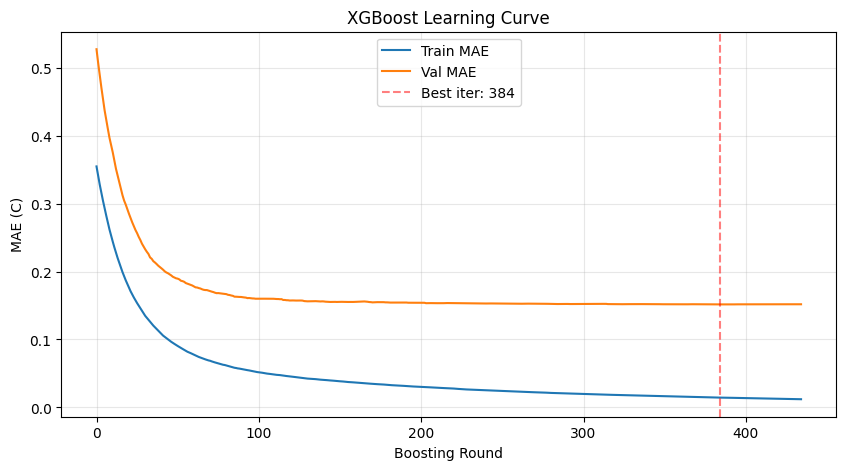

In [ ]:
# ============================================================
# XGBOOST TRAINING
# ============================================================

# Sample weights: quadratic penalty for elevated Tcore
sample_weights = 1.0 + ELEVATED_WEIGHT_ALPHA * np.maximum(0, y_train - ELEVATED_WEIGHT_THRESHOLD) ** 2

print(f"Sample weights: min={sample_weights.min():.2f}, max={sample_weights.max():.2f}, "
      f"mean={sample_weights.mean():.2f}")

# XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'mae',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_alpha': 0.1,        # L1 regularization
    'reg_lambda': 1.0,       # L2 regularization
    'seed': RANDOM_SEED,
    'n_jobs': -1,
    'verbosity': 0,
}

dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights, feature_names=feature_cols)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=feature_cols)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_cols)

print("\nTraining XGBoost...")
evals_result = {}
model = xgb.train(
    params, dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    evals_result=evals_result,
    early_stopping_rounds=50,
    verbose_eval=50,
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best val MAE: {model.best_score:.4f} C")

# Learning curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(evals_result['train']['mae'], label='Train MAE')
ax.plot(evals_result['val']['mae'], label='Val MAE')
ax.axvline(model.best_iteration, color='red', linestyle='--', alpha=0.5, label=f'Best iter: {model.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('MAE (C)')
ax.set_title('XGBoost Learning Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 7. Feature Importance

--- Feature Importance (by gain) ---
  SkinTemp_mean            :        3.0  ########################################
  Sex_Encoded              :        2.0  ##########################
  cumulative_HR            :        1.6  #####################
  HR_mean                  :        1.2  ################
  Acclimation_Encoded      :        1.0  #############
  time_in_session          :        0.6  ########
  Age                      :        0.6  #######
  HR_max                   :        0.5  ######
  SkinTemp_last            :        0.5  ######
  BMI                      :        0.5  ######
  VO2Peak                  :        0.4  ####
  Env_Temp_last            :        0.3  ###
  Perceptual_TC_last       :        0.2  ###
  Training_Encoded         :        0.2  ###
  Perceptual_TS_last       :        0.2  ##
  work_ratio               :        0.2  ##
  HR_last                  :        0.2  ##
  HR_std                   :        0.1  #
  SkinTemp_slope           :        0.

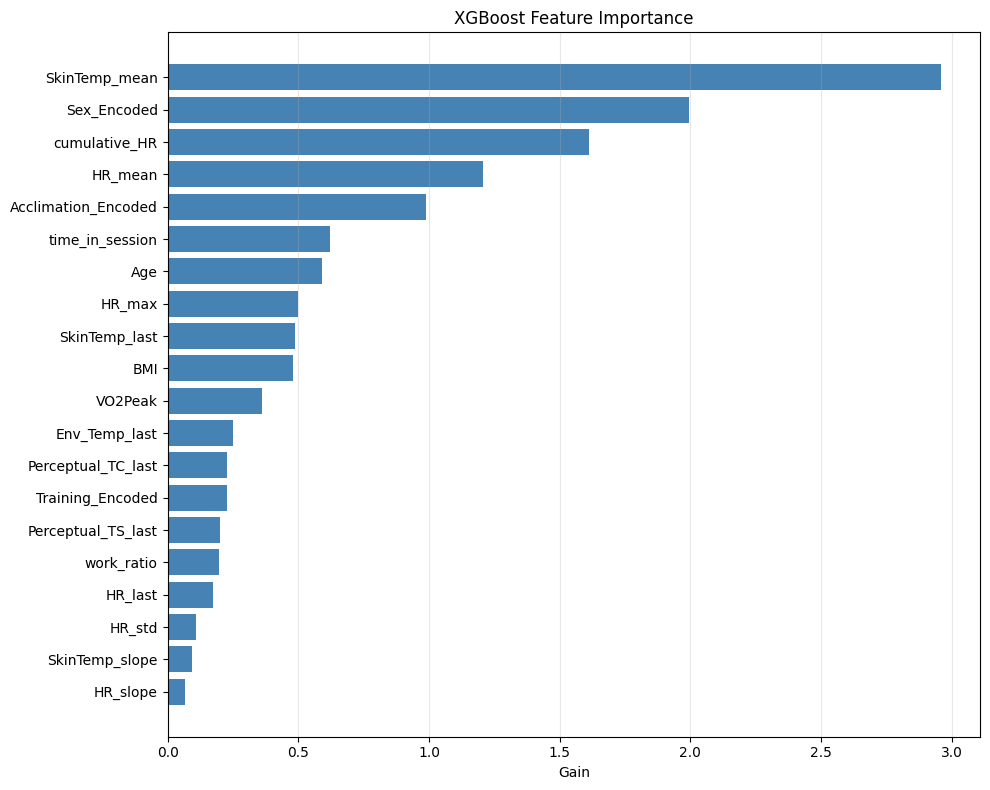

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = model.get_score(importance_type='gain')
imp_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'gain': list(importance.values())
}).sort_values('gain', ascending=False)

print("--- Feature Importance (by gain) ---")
for _, row in imp_df.iterrows():
    bar = '#' * int(row['gain'] / imp_df['gain'].max() * 40)
    print(f"  {row['feature']:25s}: {row['gain']:10.1f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 8))
imp_df_plot = imp_df.sort_values('gain', ascending=True)
ax.barh(imp_df_plot['feature'], imp_df_plot['gain'], color='steelblue')
ax.set_xlabel('Gain')
ax.set_title('XGBoost Feature Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Test Set Evaluation

In [ ]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

y_pred = model.predict(dtest)

# --- Regression Metrics ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Test Regression Metrics ---")
print(f"  MAE:  {mae:.4f} C")
print(f"  RMSE: {rmse:.4f} C")
print(f"  R2:   {r2:.4f}")

# --- Threshold Classification ---
print(f"\n--- Threshold-Based Classification ---")
thresh_results = {}
for t in [38.0, 38.5, 39.0]:
    actual_pos = y_test >= t
    pred_pos = y_pred >= t
    tp = np.sum(actual_pos & pred_pos)
    fp = np.sum(~actual_pos & pred_pos)
    fn = np.sum(actual_pos & ~pred_pos)
    tn = np.sum(~actual_pos & ~pred_pos)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"\n  Threshold: {t:.1f} C")
    print(f"    Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}")
    print(f"    PPV: {ppv:.3f}")
    print(f"    TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    thresh_results[t] = {'sensitivity': sensitivity, 'specificity': specificity, 'ppv': ppv}

# --- False Alarm Rate ---
for threshold in [38.5, 39.0]:
    actual_safe = y_test < threshold
    pred_alarm = y_pred >= threshold
    false_alarms = np.sum(actual_safe & pred_alarm)
    safe_hours = np.sum(actual_safe) / 60
    rate = false_alarms / safe_hours if safe_hours > 0 else 0
    print(f"\n--- False Alarm Rate (threshold={threshold} C) ---")
    print(f"  False alarms: {false_alarms}, Safe hours: {safe_hours:.1f}")
    print(f"  Rate: {rate:.2f} per safe-hour")

--- Test Regression Metrics ---
  MAE:  0.2303 C
  RMSE: 0.2908 C
  R2:   0.4648

--- Threshold-Based Classification ---

  Threshold: 38.0 C
    Sensitivity: 0.635 | Specificity: 0.856
    PPV: 0.844
    TP=108, FP=20, FN=62, TN=119

  Threshold: 38.5 C
    Sensitivity: 0.419 | Specificity: 0.996
    PPV: 0.947
    TP=18, FP=1, FN=25, TN=265

  Threshold: 39.0 C
    Sensitivity: 0.000 | Specificity: 0.997
    PPV: 0.000
    TP=0, FP=1, FN=10, TN=298

--- False Alarm Rate (threshold=38.5 C) ---
  False alarms: 1, Safe hours: 4.4
  Rate: 0.23 per safe-hour

--- False Alarm Rate (threshold=39.0 C) ---
  False alarms: 1, Safe hours: 5.0
  Rate: 0.20 per safe-hour


## 9. Bland-Altman & Calibration Plots

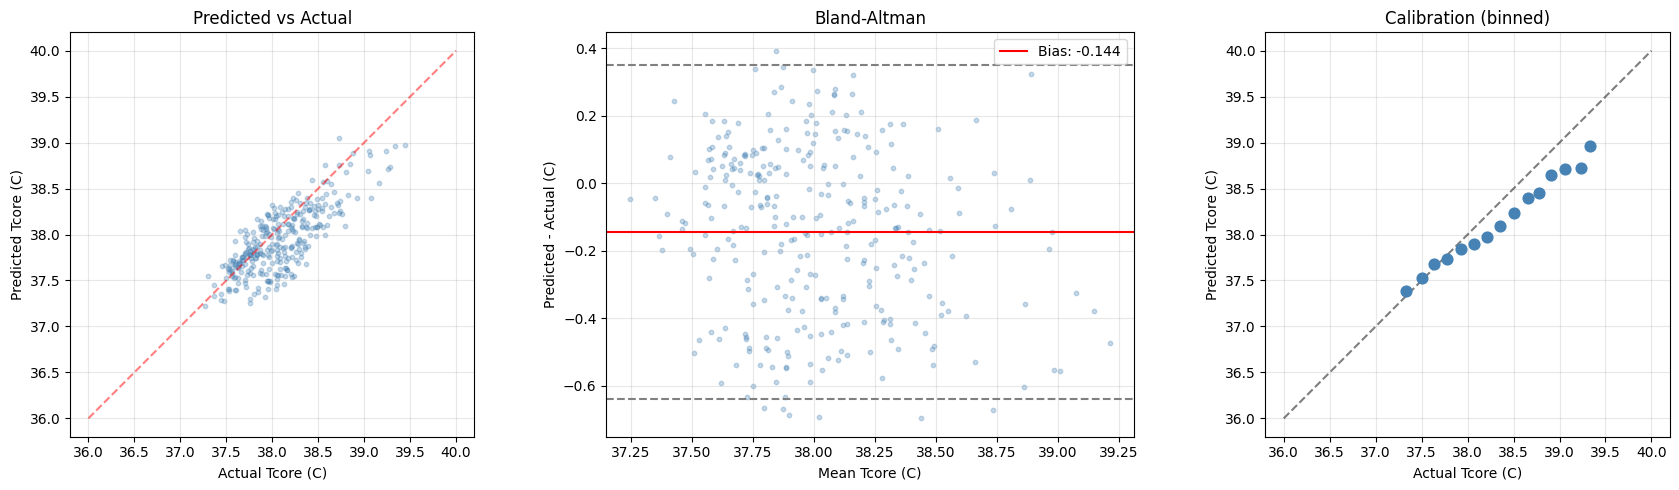


Bland-Altman: Bias=-0.1442, LoA=[-0.6391, 0.3508]


In [ ]:
# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Scatter plot ---
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=10, c='steelblue')
ax.plot([36, 40], [36, 40], 'r--', alpha=0.5)
ax.set_xlabel('Actual Tcore (C)')
ax.set_ylabel('Predicted Tcore (C)')
ax.set_title('Predicted vs Actual')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Bland-Altman ---
ax = axes[1]
mean_vals = (y_test + y_pred) / 2
diff = y_pred - y_test
mean_diff = np.mean(diff)
std_diff = np.std(diff)
ax.scatter(mean_vals, diff, alpha=0.3, s=10, c='steelblue')
ax.axhline(mean_diff, color='red', linestyle='-', label=f'Bias: {mean_diff:.3f}')
ax.axhline(mean_diff + 1.96 * std_diff, color='gray', linestyle='--')
ax.axhline(mean_diff - 1.96 * std_diff, color='gray', linestyle='--')
ax.set_xlabel('Mean Tcore (C)')
ax.set_ylabel('Predicted - Actual (C)')
ax.set_title('Bland-Altman')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Calibration ---
ax = axes[2]
bins = np.linspace(y_test.min(), y_test.max(), 16)
bin_actual, bin_pred = [], []
for i in range(len(bins)-1):
    mask = (y_test >= bins[i]) & (y_test < bins[i+1])
    if mask.sum() > 0:
        bin_actual.append(y_test[mask].mean())
        bin_pred.append(y_pred[mask].mean())
ax.plot([36, 40], [36, 40], 'k--', alpha=0.5)
ax.scatter(bin_actual, bin_pred, s=60, c='steelblue', zorder=5)
ax.set_xlabel('Actual Tcore (C)')
ax.set_ylabel('Predicted Tcore (C)')
ax.set_title('Calibration (binned)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBland-Altman: Bias={mean_diff:.4f}, LoA=[{mean_diff-1.96*std_diff:.4f}, {mean_diff+1.96*std_diff:.4f}]")

## 10. Per-Participant MAE

In [ ]:
# ============================================================
# PER-PARTICIPANT ERROR
# ============================================================

print("--- Per-Participant MAE (Test Set) ---")
for pid in sorted(tab_test['Participant'].unique()):
    pmask = tab_test['Participant'] == pid
    p_true = tab_test.loc[pmask, 'target'].values
    p_features = tab_test.loc[pmask, feature_cols].values.astype(np.float32)
    # Impute NaN
    for i in range(p_features.shape[1]):
        p_features[np.isnan(p_features[:, i]), i] = train_medians[i]
    p_pred = model.predict(xgb.DMatrix(p_features, feature_names=feature_cols))
    p_mae = mean_absolute_error(p_true, p_pred)
    print(f"  P{int(pid)}: MAE={p_mae:.3f} C  (mean Tcore={p_true.mean():.2f}, "
          f"max={p_true.max():.2f}, n={len(p_true)})")

--- Per-Participant MAE (Test Set) ---
  P8: MAE=0.411 C  (mean Tcore=38.07, max=38.57, n=59)
  P37: MAE=0.231 C  (mean Tcore=38.13, max=38.88, n=70)
  P44: MAE=0.160 C  (mean Tcore=38.00, max=39.34, n=99)
  P46: MAE=0.175 C  (mean Tcore=37.99, max=38.26, n=15)
  P49: MAE=0.190 C  (mean Tcore=38.22, max=39.45, n=51)
  P50: MAE=0.166 C  (mean Tcore=38.06, max=38.74, n=15)


## 11. Cross-Validation (Leave-Participants-Out)

In [ ]:
# ============================================================
# GROUPED K-FOLD CROSS-VALIDATION
# ============================================================
# Use ALL data (train+val+test) with GroupKFold on Participant

print("Running 5-fold participant-grouped cross-validation...")

# Combine all data
tab_all = pd.concat([tab_train, tab_val, tab_test], ignore_index=True)
X_all = tab_all[feature_cols].values.astype(np.float32)
y_all = tab_all['target'].values.astype(np.float32)
groups = tab_all['Participant'].values

# Impute NaN
all_medians = np.nanmedian(X_all, axis=0)
for i in range(X_all.shape[1]):
    X_all[np.isnan(X_all[:, i]), i] = all_medians[i]

gkf = GroupKFold(n_splits=5)
cv_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all, groups)):
    X_tr_cv, y_tr_cv = X_all[train_idx], y_all[train_idx]
    X_te_cv, y_te_cv = X_all[test_idx], y_all[test_idx]

    # Sample weights
    w_cv = 1.0 + ELEVATED_WEIGHT_ALPHA * np.maximum(0, y_tr_cv - ELEVATED_WEIGHT_THRESHOLD) ** 2

    d_tr = xgb.DMatrix(X_tr_cv, label=y_tr_cv, weight=w_cv, feature_names=feature_cols)
    d_te = xgb.DMatrix(X_te_cv, label=y_te_cv, feature_names=feature_cols)

    m_cv = xgb.train(params, d_tr, num_boost_round=model.best_iteration + 1,
                     verbose_eval=False)

    preds_cv = m_cv.predict(d_te)
    mae_cv = mean_absolute_error(y_te_cv, preds_cv)
    rmse_cv = np.sqrt(mean_squared_error(y_te_cv, preds_cv))
    r2_cv = r2_score(y_te_cv, preds_cv)

    # Sensitivity at 38.5
    pos = y_te_cv >= 38.5
    pred_pos = preds_cv >= 38.5
    sens_385 = np.sum(pos & pred_pos) / np.sum(pos) if np.sum(pos) > 0 else 0

    test_participants = sorted(set(groups[test_idx]))
    cv_results.append({
        'fold': fold, 'mae': mae_cv, 'rmse': rmse_cv, 'r2': r2_cv,
        'sens_385': sens_385, 'n_test': len(test_idx),
        'participants': test_participants,
    })

    print(f"  Fold {fold}: MAE={mae_cv:.4f}, RMSE={rmse_cv:.4f}, R2={r2_cv:.4f}, "
          f"Sens@38.5={sens_385:.3f} | Test P: {test_participants}")

print(f"\n--- Cross-Validation Summary ---")
maes = [r['mae'] for r in cv_results]
rmses = [r['rmse'] for r in cv_results]
r2s = [r['r2'] for r in cv_results]
sens = [r['sens_385'] for r in cv_results]
print(f"  MAE:       {np.mean(maes):.4f} +/- {np.std(maes):.4f}")
print(f"  RMSE:      {np.mean(rmses):.4f} +/- {np.std(rmses):.4f}")
print(f"  R2:        {np.mean(r2s):.4f} +/- {np.std(r2s):.4f}")
print(f"  Sens@38.5: {np.mean(sens):.3f} +/- {np.std(sens):.3f}")

Running 5-fold participant-grouped cross-validation...
  Fold 0: MAE=0.2194, RMSE=0.2742, R2=0.5149, Sens@38.5=0.488 | Test P: [np.int64(4), np.int64(7), np.int64(13), np.int64(14), np.int64(29), np.int64(30), np.int64(36), np.int64(40)]
  Fold 1: MAE=0.2423, RMSE=0.2985, R2=0.6214, Sens@38.5=0.519 | Test P: [np.int64(5), np.int64(9), np.int64(11), np.int64(15), np.int64(32), np.int64(34), np.int64(38), np.int64(50)]
  Fold 2: MAE=0.1804, RMSE=0.2258, R2=0.6688, Sens@38.5=0.635 | Test P: [np.int64(2), np.int64(16), np.int64(17), np.int64(18), np.int64(33), np.int64(35), np.int64(45), np.int64(47)]
  Fold 3: MAE=0.2218, RMSE=0.2915, R2=0.5997, Sens@38.5=0.444 | Test P: [np.int64(1), np.int64(10), np.int64(37), np.int64(41), np.int64(42), np.int64(44), np.int64(46), np.int64(49)]
  Fold 4: MAE=0.2322, RMSE=0.3080, R2=0.5485, Sens@38.5=0.587 | Test P: [np.int64(3), np.int64(6), np.int64(8), np.int64(12), np.int64(31), np.int64(39), np.int64(43), np.int64(48)]

--- Cross-Validation Summary

## 12. Comparison vs Previous Models

In [ ]:
# ============================================================
# COMPARISON TABLE
# ============================================================

print("=" * 70)
print("  MODEL COMPARISON")
print("=" * 70)
print(f"{'Metric':<25} {'CNN V2':>12} {'CNN V3 (TCN)':>12} {'XGBoost':>12}")
print("-" * 70)
print(f"{'MAE (C)':<25} {'0.2585':>12} {'TBD':>12} {mae:>12.4f}")
print(f"{'RMSE (C)':<25} {'0.3204':>12} {'TBD':>12} {rmse:>12.4f}")
print(f"{'R2':<25} {'0.3547':>12} {'TBD':>12} {r2:>12.4f}")
print(f"{'Sens @ 38.0':<25} {'0.438':>12} {'TBD':>12} {thresh_results[38.0]['sensitivity']:>12.3f}")
print(f"{'Sens @ 38.5':<25} {'0.167':>12} {'TBD':>12} {thresh_results[38.5]['sensitivity']:>12.3f}")
print(f"{'Sens @ 39.0':<25} {'0.000':>12} {'TBD':>12} {thresh_results[39.0]['sensitivity']:>12.3f}")
print(f"{'Bias (C)':<25} {'-0.1885':>12} {'TBD':>12} {mean_diff:>12.4f}")
print(f"{'Epochs/Rounds':<25} {'17 (best=2)':>12} {'TBD':>12} {model.best_iteration:>12}")
print("-" * 70)
print(f"{'time_in_session?':<25} {'NO':>12} {'NO':>12} {'YES':>12}")
print(f"{'Perceptual input?':<25} {'NO':>12} {'NO':>12} {'YES':>12}")
print(f"{'Activity level?':<25} {'NO':>12} {'NO':>12} {'YES':>12}")
print(f"{'Weighted loss?':<25} {'NO':>12} {'YES':>12} {'YES':>12}")
print("=" * 70)

  MODEL COMPARISON
Metric                          CNN V2 CNN V3 (TCN)      XGBoost
----------------------------------------------------------------------
MAE (C)                         0.2585          TBD       0.2303
RMSE (C)                        0.3204          TBD       0.2908
R2                              0.3547          TBD       0.4648
Sens @ 38.0                      0.438          TBD        0.635
Sens @ 38.5                      0.167          TBD        0.419
Sens @ 39.0                      0.000          TBD        0.000
Bias (C)                       -0.1885          TBD      -0.1442
Epochs/Rounds              17 (best=2)          TBD          384
----------------------------------------------------------------------
time_in_session?                    NO           NO          YES
Perceptual input?                   NO           NO          YES
Activity level?                     NO           NO          YES
Weighted loss?                      NO          YES        

## 13. Summary & Next Steps

In [ ]:
# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("  PHASE 0 COMPLETE — XGBoost Baseline")
print("=" * 60)

print(f"\n  Test Set Results:")
print(f"    MAE:  {mae:.4f} C")
print(f"    RMSE: {rmse:.4f} C")
print(f"    R2:   {r2:.4f}")
print(f"    Sensitivity @ 38.5: {thresh_results[38.5]['sensitivity']:.3f}")
print(f"    Sensitivity @ 39.0: {thresh_results[39.0]['sensitivity']:.3f}")

cv_mae = np.mean(maes)
cv_sens = np.mean(sens)
print(f"\n  Cross-Validated (5-fold, participant-grouped):")
print(f"    MAE:  {cv_mae:.4f} +/- {np.std(maes):.4f}")
print(f"    Sens@38.5: {cv_sens:.3f} +/- {np.std(sens):.3f}")

print(f"\n  Top 5 Features (by gain):")
for _, row in imp_df.head(5).iterrows():
    print(f"    {row['feature']}: {row['gain']:.1f}")

print(f"\n  Key insight: time_in_session and enriched features unlock")
print(f"  the signal that CNN V1-V3 could never access.")

if cv_mae < 0.25 and cv_sens > 0.4:
    print(f"\n  VERDICT: Signal confirmed. Proceed to Phase 1 (sequence model).")
elif cv_mae < 0.30:
    print(f"\n  VERDICT: Moderate signal. Feature engineering helps but")
    print(f"  sequence modeling may capture additional temporal patterns.")
else:
    print(f"\n  VERDICT: Features need more work before sequence modeling.")

print("\n" + "=" * 60)

  PHASE 0 COMPLETE — XGBoost Baseline

  Test Set Results:
    MAE:  0.2303 C
    RMSE: 0.2908 C
    R2:   0.4648
    Sensitivity @ 38.5: 0.419
    Sensitivity @ 39.0: 0.000

  Cross-Validated (5-fold, participant-grouped):
    MAE:  0.2192 +/- 0.0210
    Sens@38.5: 0.535 +/- 0.068

  Top 5 Features (by gain):
    SkinTemp_mean: 3.0
    Sex_Encoded: 2.0
    cumulative_HR: 1.6
    HR_mean: 1.2
    Acclimation_Encoded: 1.0

  Key insight: time_in_session and enriched features unlock
  the signal that CNN V1-V3 could never access.

  VERDICT: Signal confirmed. Proceed to Phase 1 (sequence model).

